In [56]:
import fastf1
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from xgboost import XGBClassifier, XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import shap
import matplotlib.pyplot as plt

In [57]:
data = pd.read_parquet('/Users/dimkostir/Desktop/Projects/f1-predictions/data/processed/master_tables/master_table_24_25.parquet')


In [58]:
training_data = data[data["Year"] == 2024]
test_data = data[data["Year"] == 2025]

X_train = training_data.drop(columns = ["Driver", "TeamName_x", "Status", "Year", "Location", "Finish_Position", "dnf"], axis = 1)
y_train = training_data["Finish_Position"].astype(int)

X_test = test_data.drop(columns = ["Driver", "TeamName_x", "Status", "Year", "Location", "Finish_Position","dnf"], axis = 1)
y_test = test_data["Finish_Position"].astype(int)

bst = XGBRegressor(n_estimators = 100, max_depth = 2, learning_rate = 0.1)
bst.fit(X_train, y_train)

predictions = bst.predict(X_test)

In [59]:
test_data = test_data.copy()
test_data["Prediction"] = predictions

spearman_per_race = test_data.groupby("Location").apply(
    lambda x: spearmanr(x["Finish_Position"], x["Prediction"])[0]
)

print(spearman_per_race)
print(f"\nΜέσος Spearman: {spearman_per_race.mean():.3f}")

Location
Austin               0.924812
Baku                 0.625047
Barcelona            0.636842
Budapest             0.834586
Imola                0.696241
Jeddah               0.950376
Las Vegas            0.218045
Lusail               0.709774
Marina Bay           0.801504
Melbourne            0.754887
Mexico City          0.815038
Miami Gardens        0.921805
Monaco               0.840602
Montréal             0.759398
Monza                0.929323
Sakhir               0.655639
Shanghai             0.484211
Silverstone          0.747368
Spa-Francorchamps    0.628571
Spielberg            0.944361
Suzuka               0.949981
São Paulo            0.833083
Yas Island           0.741353
Zandvoort            0.284211
dtype: float64

Μέσος Spearman: 0.737


/var/folders/s0/k6p2569n6w1br5pz86sgwm400000gn/T/ipykernel_8051/651870808.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spearman_per_race = test_data.groupby("Location").apply(


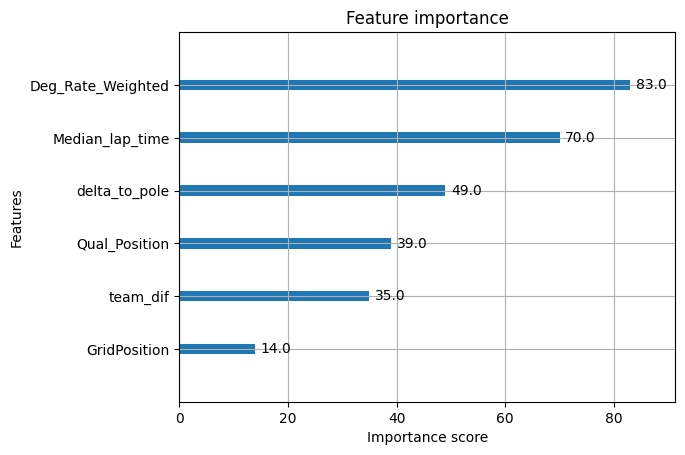

In [60]:
plot_importance(bst)
plt.show()